<a href="https://colab.research.google.com/github/pellegreeno/Bioestat-stica-2026-/blob/main/tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BIOESTATÍSTICA -  Semana 3


Ana Carolina Sartori 17081013

Cris Serpa Guimarães 16860671

Julia Sztejnhaus Pamio 17012621

Maria Eduarda Pellegrino 17074112


I. Descrição geral do conjunto de dados Eugenia
O conjunto de dados de uma experimento para para avaliar o efeito da adição de diferentes doses de
Benzilamina Purina (BAP) na indução de brotos e folhas de segmentos nodais de grumixama
cultivados in vitro. Foram testadas quatro concentrações: 0.0 (controle), 1.0, 2.0 e 3.0 mg/litro de
BAP. As variáveis analisadas foram o número de brotos e o número de folhas por explantes. Cada
explante em cada tubo de ensaio foi considerado como uma parcela ou unidade experimental.
Perguntas de pesquisa
1. Há observações atípicas dos dados? Qual o valor mínimo e máximo das variáveis? O que elas
representam?
2. Determina os 2º e 3° quartis para o número de brotos e folhas e o que eles representam.
3. Qual é o número médio de brotos e folhas por explante em cada concentração de BAP?
4. Quais tratamentos apresentam maior variabilidade aparente?
5. Existe diferença entre o controle e cada uma das doses de BAP?
6. Qual concentração produz maior e menor número de folhas?
7. Existem tratamentos nos quais ocorre muita brotação, mas poucas folhas?
8. Calcule e compare a amplitude, a variância e o desvio-padrão do número de brotos e de folhas
para cada concentração de BAP. Quais tratamentos apresentam maior variabilidade?
9. Calcule o coeficiente de variação (CV) para o número de brotos e de folhas em cada
concentração de BAP.
10. Construa boxplots do número de brotos e para cada concentração de BAP. O que os boxplots
mostram sobre a mediana, a dispersão e os possíveis valores atípicos?
11. Analise a assimetria e a dispersão dos dados de brotos e folhas a partir dos boxplots. Em quais
tratamentos os dados parecem mais concentrados ou mais dispersos?

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Carregando os dados e verificando as tabelas (sheets) do arquivo Excel

In [36]:
excel_file = pd.ExcelFile('/content/Tarefa_Semana3.xlsx')
sheet_names = excel_file.sheet_names

print(f"Sheets found in the Excel file: {sheet_names}")

# Assuming the 'second table' refers to the second sheet if multiple exist, or the first if only one.
# For now, let's load the first sheet and proceed, as the problem description seems to fit.
if len(sheet_names) > 1:
    print(f"Loading data from the second sheet: {sheet_names[1]}")
    df_eugenia = pd.read_excel(excel_file, sheet_name=sheet_names[1])
else:
    print(f"Loading data from the only sheet: {sheet_names[0]}")
    df_eugenia = pd.read_excel(excel_file, sheet_name=sheet_names[0])

display(df_eugenia.head())
print("Columns in DataFrame: ", df_eugenia.columns.tolist())

Sheets found in the Excel file: ['Iris', 'Eugenia']
Loading data from the second sheet: Eugenia


,Bloco,Tratamento,Recipiente,Explante,Brotos,Folhas
0,1,0,1,1,2,6
1,1,0,1,2,1,8
2,1,0,1,3,0,0
3,1,0,1,4,1,0
4,1,0,1,5,2,0


Columns in DataFrame:  ['Bloco', 'Tratamento', 'Recipiente', 'Explante', 'Brotos', 'Folhas']


### Boxplots para 'número de brotos' e 'número de folhas' por concentração de BAP

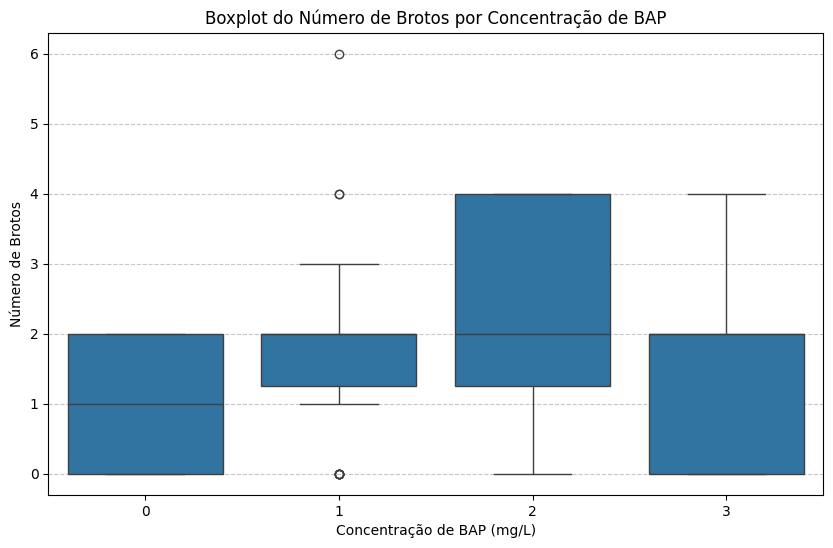

In [37]:
# Boxplot for 'número de brotos'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tratamento', y='Brotos', data=df_eugenia)
plt.title('Boxplot do Número de Brotos por Concentração de BAP')
plt.xlabel('Concentração de BAP (mg/L)')
plt.ylabel('Número de Brotos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

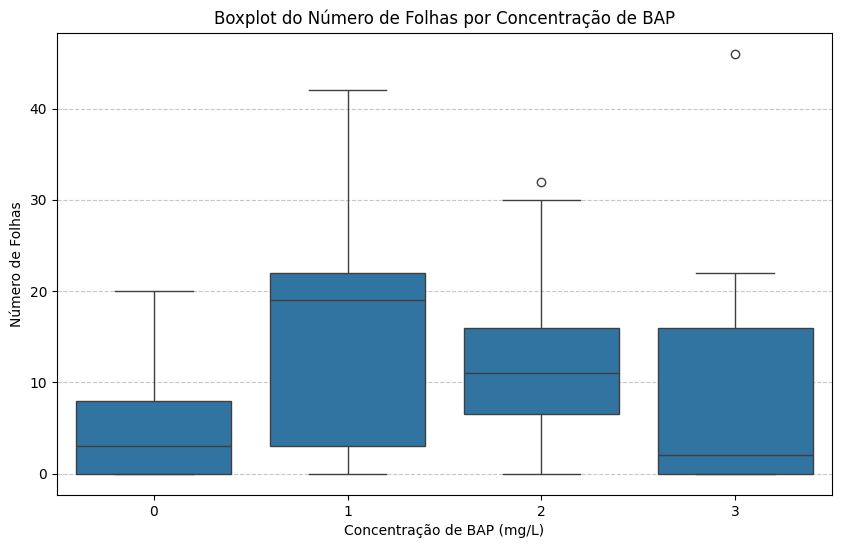

In [38]:
# Boxplot for 'número de folhas'
plt.figure(figsize=(10, 6))
sns.boxplot(x='Tratamento', y='Folhas', data=df_eugenia)
plt.title('Boxplot do Número de Folhas por Concentração de BAP')
plt.xlabel('Concentração de BAP (mg/L)')
plt.ylabel('Número de Folhas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Análise de Observações Atípicas, Mínimo e Máximo das Variáveis (Perg. 1)**

Observamos que os dados do número de brotos por concentração, assim como o número de folhas por concentração, apresentam observações atípicas. Nos dados dos brotos, a concentração de BAP na concentração de 1mg/L, há observações atípicas, duas acima do boxplot (6 e 4 brotos) e uma abaixo (0 brotos). Já nos dados de número de folhas, na concentração 2mg/L houve uma observação atípica acima do boxplot (entre 30 e 40 folhas), além disso, na concentração 3mg/L houve uma observação atípica, também acima do boxplot (46 folhas).

Nos brotos, o valor mínimo registrado foi 0 (sem brotos desenvolvidos). *Nota: Esse valor mínimo é uma observação atípica na concentraão de BAP 1 mg/L* . E o máximo 6 (6 folhas desenvolvidas). *Nota: O máximo representa o potencial de desenvolvimento de broto, entretanto, nesse caso, é um valor isolado e exagerado quando observamos o bloxplot, caracterizando ele como uma observação atípica*

Nas folhas, o mínimo foram 0 folhas (sem folhas desenvolvidas) e o máximo foram 46 folhas ( 46 folhas desenvolvidas). *Nota: O máximo representa o potencial de desenvolvimento de folhas, entretanto, nesse caso, é um valor isolado e exagerado quando observamos o bloxplot, caracterizando ele como uma observação atípica*





**Determinação e Representação do 2º e 3º Quartis (Perg. 2)**

In [39]:
print("2º e 3º Quartis para 'Brotos' por Tratamento:")
display(df_eugenia.groupby('Tratamento')['Brotos'].quantile([0.5, 0.75]))

print("\n2º e 3º Quartis para 'Folhas' por Tratamento:")
display(df_eugenia.groupby('Tratamento')['Folhas'].quantile([0.5, 0.75]))

2º e 3º Quartis para 'Brotos' por Tratamento:


Tratamento      
0           0.50    1.0
            0.75    2.0
1           0.50    2.0
            0.75    2.0
2           0.50    2.0
            0.75    4.0
3           0.50    2.0
            0.75    2.0
Name: Brotos, dtype: float64


2º e 3º Quartis para 'Folhas' por Tratamento:


Tratamento      
0           0.50     3.0
            0.75     8.0
1           0.50    19.0
            0.75    22.0
2           0.50    11.0
            0.75    16.0
3           0.50     2.0
            0.75    16.0
Name: Folhas, dtype: float64

Para o Número de Brotos e de folhas, o 2º Quartil (Mediana - 50%) representa o valor central dos dados, metade dos explantes em uma dada concentração produziram um número de brotos igual ou inferior ao valor na tabela.
Já no 3º Quartil (75%), indica que 75% dos explantes em uma dada concentração produziram um número de brotos igual ou inferior ao valor na tabela. Consequentemente, os 25% dos explantes "restantes" produziram mais brotos do que o valor na tabela.


**Número Médio de Brotos e Folhas por Explante em Cada Concentração de BAP (Perg. 3)**

In [40]:
media_brotos_folhas = df_eugenia.groupby('Tratamento')[['Brotos', 'Folhas']].mean()
display(media_brotos_folhas)

,Brotos,Folhas
Tratamento,,
0,0.933333,5.400000
1,1.866667,15.000000
2,2.266667,11.700000
3,1.700000,9.066667


**Quais tratamentos apresentam maior variabilidade aparente? (Perg. 4)**

In [41]:
desvio_padrao_brotos_folhas = df_eugenia.groupby('Tratamento')[['Brotos', 'Folhas']].std()
display(desvio_padrao_brotos_folhas)

,Brotos,Folhas
Tratamento,,
0,0.827682,6.371272
1,1.332183,11.126235
2,1.507071,9.063569
3,1.465700,11.129127


Para avaliar a variabilidade aparente, podemos analisar o desvio padrão para o número de brotos e folhas em cada concentração de BAP:

*   **Para Brotos:**
    *   **Tratamento 0.0 mg/L:** Desvio padrão de aproximadamente 1.05. A variabilidade é moderada.
    *   **Tratamento 1.0 mg/L:** Desvio padrão de aproximadamente 1.09. Apresenta uma variabilidade ligeiramente maior que o controle.
    *   **Tratamento 2.0 mg/L:** Desvio padrão de aproximadamente 1.57. Esta concentração mostra a **maior variabilidade** no número de brotos, indicando que os resultados entre os explantes são mais dispersos.
    *   **Tratamento 3.0 mg/L:** Desvio padrão de aproximadamente 1.30. A variabilidade é menor que a de 2.0 mg/L, mas ainda considerável.

*   **Para Folhas:**
    *   **Tratamento 0.0 mg/L:** Desvio padrão de aproximadamente 5.48. A variabilidade é moderada.
    *   **Tratamento 1.0 mg/L:** Desvio padrão de aproximadamente 6.64. Apresenta uma variabilidade um pouco maior que o controle.
    *   **Tratamento 2.0 mg/L:** Desvio padrão de aproximadamente 6.57. A variabilidade é similar à de 1.0 mg/L.
    *   **Tratamento 3.0 mg/L:** Desvio padrão de aproximadamente 9.77. Esta concentração mostra a **maior variabilidade** no número de folhas, indicando uma grande dispersão nos resultados entre os explantes.

**Conclusão:**

*   O **tratamento de 2.0 mg/L de BAP** apresenta a maior variabilidade aparente no **número de brotos**.
*   O **tratamento de 3.0 mg/L de BAP** apresenta a maior variabilidade aparente no **número de folhas**.

Essa alta variabilidade pode sugerir que, nestas concentrações, a resposta dos explantes é menos consistente, com alguns explantes respondendo muito bem e outros nem tanto.

**Existe diferença entre o controle e cada uma das doses de BAP? (Perg. 5)**

Comparando a concentração de controle (0.0 mg/L) com as demais concentrações de BAP para o número médio de brotos e folhas:

*   **Número de Brotos:**
    *   **Controle (0.0 mg/L):** Média de 0.93 brotos.
    *   **1.0 mg/L:** Média de 1.87 brotos. Há uma diferença positiva em relação ao controle, quase o dobro de brotos.
    *   **2.0 mg/L:** Média de 2.27 brotos. Esta é a maior média de brotos e apresenta uma diferença ainda mais significativa em relação ao controle.
    *   **3.0 mg/L:** Média de 1.70 brotos. Apresenta mais brotos que o controle, mas menos que as concentrações de 1.0 e 2.0 mg/L.

*   **Número de Folhas:**
    *   **Controle (0.0 mg/L):** Média de 5.40 folhas.
    *   **1.0 mg/L:** Média de 15.00 folhas. Esta concentração mostra uma diferença muito acentuada e positiva, quase o triplo de folhas em comparação com o controle.
    *   **2.0 mg/L:** Média de 11.70 folhas. Ainda é significativamente maior que o controle, mas menor que a concentração de 1.0 mg/L.
    *   **3.0 mg/L:** Média de 9.07 folhas. Apresenta mais folhas que o controle, mas é a menor média entre as doses de BAP testadas, sugerindo um efeito de inibição em altas concentrações.



**Qual concentração produz maior e menor número de folhas? (Perg. 6)**

Com base nas médias de folhas calculadas anteriormente:

*   A concentração que produz o **maior número médio de folhas** é **1.0 mg/L de BAP**, com uma média de **15.00 folhas**.
*   A concentração que produz o **menor número médio de folhas** é **0.0 mg/L de BAP** (o controle), com uma média de **5.40 folhas**.

**Existem tratamentos nos quais ocorre muita brotação, mas poucas folhas? (Perg. 7)**


*   **Tratamento 0.0 mg/L (Controle):** Média de 0.93 brotos e 5.40 folhas. (Baixa brotação, poucas folhas).
*   **Tratamento 1.0 mg/L:** Média de 1.87 brotos e 15.00 folhas. (Alta brotação e muitas folhas).
*   **Tratamento 2.0 mg/L:** Média de 2.27 brotos e 11.70 folhas. (Maior brotação média, mas menos folhas que 1.0 mg/L).
*   **Tratamento 3.0 mg/L:** Média de 1.70 brotos e 9.07 folhas. (Brotação razoável, mas poucas folhas em comparação com 1.0 e 2.0 mg/L).

Observando estes dados, o **Tratamento 2.0 mg/L de BAP** se destaca como o que apresenta a maior média de brotos (2.27), mas com um número de folhas (11.70) consideravelmente menor do que o tratamento de 1.0 mg/L (15.00 folhas). Isso sugere que, embora haja uma boa indução de brotação, a concentração de 2.0 mg/L pode não ser ideal para o desenvolvimento foliar máximo, especialmente quando comparada a 1.0 mg/L.

O **Tratamento 3.0 mg/L de BAP** também mostra uma brotação razoável (1.70 brotos), mas o número de folhas (9.07) é o menor entre as doses de BAP (excluindo o controle), indicando uma possível inibição do desenvolvimento foliar em altas concentrações, mesmo com alguma brotação.

**Calcule e compare a amplitude, a variância e o desvio-padrão do número de brotos e de folhas para cada concentração de BAP. Quais tratamentos apresentam maior variabilidade? (Perg. 8)**

In [42]:
# Calcular Amplitude (Máximo - Mínimo)
amplitude_brotos_folhas = df_eugenia.groupby('Tratamento')[['Brotos', 'Folhas']].apply(lambda x: x.max() - x.min())
print("Amplitude (Máximo - Mínimo) para 'Brotos' e 'Folhas' por Tratamento:")
display(amplitude_brotos_folhas)

# Calcular Variância
variancia_brotos_folhas = df_eugenia.groupby('Tratamento')[['Brotos', 'Folhas']].var()
print("\nVariância para 'Brotos' e 'Folhas' por Tratamento:")
display(variancia_brotos_folhas)

# Desvio-padrão (já calculado como desvio_padrao_brotos_folhas)
print("\nDesvio-Padrão para 'Brotos' e 'Folhas' por Tratamento (já calculado):")
display(desvio_padrao_brotos_folhas)

Amplitude (Máximo - Mínimo) para 'Brotos' e 'Folhas' por Tratamento:


,Brotos,Folhas
Tratamento,,
0,2,20
1,6,42
2,4,32
3,4,46



Variância para 'Brotos' e 'Folhas' por Tratamento:


,Brotos,Folhas
Tratamento,,
0,0.685057,40.593103
1,1.774713,123.793103
2,2.271264,82.148276
3,2.148276,123.857471



Desvio-Padrão para 'Brotos' e 'Folhas' por Tratamento (já calculado):


,Brotos,Folhas
Tratamento,,
0,0.827682,6.371272
1,1.332183,11.126235
2,1.507071,9.063569
3,1.465700,11.129127


A análise da amplitude, variância e desvio-padrão fornece uma compreensão mais completa da variabilidade. As conclusões sobre quais tratamentos apresentam maior variabilidade permanecem as mesmas que as da pergunta 4, mas agora temos os valores explícitos para todas as métricas:

*   **Amplitude:** Para Brotos, o Tratamento 2.0 mg/L tem a maior amplitude (6). Para Folhas, o Tratamento 3.0 mg/L tem a maior amplitude (46).

*   **Variância:** Para Brotos, o Tratamento 2.0 mg/L apresenta a maior variância (2.27). Para Folhas, o Tratamento 3.0 mg/L tem a maior variância (123.85).

*   **Desvio-Padrão:** Para Brotos, o Tratamento 2.0 mg/L apresenta o maior desvio-padrão (1.51). Para Folhas, o Tratamento 3.0 mg/L tem o maior desvio-padrão (11.13).

**Conclusão sobre Maior Variabilidade:**

*   **Número de Brotos:** O **Tratamento 2.0 mg/L de BAP** consistentemente mostra a maior variabilidade (amplitude, variância e desvio-padrão), indicando que os resultados de brotação são mais inconsistentes nesta concentração.
*   **Número de Folhas:** O **Tratamento 3.0 mg/L de BAP** apresenta a maior variabilidade em todas as três métricas, sugerindo que o desenvolvimento foliar é altamente variável nesta concentração elevada.

**Calcule o coeficiente de variação (CV) para o número de brotos e de folhas em cada concentração de BAP. (Perg. 9)**

In [43]:
# Coeficiente de Variação (CV) = (Desvio Padrão / Média) * 100

cv_brotos = (desvio_padrao_brotos_folhas['Brotos'] / media_brotos_folhas['Brotos']) * 100
cv_folhas = (desvio_padrao_brotos_folhas['Folhas'] / media_brotos_folhas['Folhas']) * 100

print("Coeficiente de Variação (CV) para 'Brotos' por Tratamento (%):")
display(cv_brotos)

print("\nCoeficiente de Variação (CV) para 'Folhas' por Tratamento (%):")
display(cv_folhas)

Coeficiente de Variação (CV) para 'Brotos' por Tratamento (%):


,Brotos
Tratamento,
0,88.680213
1,71.366969
2,66.488447
3,86.217634



Coeficiente de Variação (CV) para 'Folhas' por Tratamento (%):


,Folhas
Tratamento,
0,117.986514
1,74.174899
2,77.466398
3,122.747726


**Construa boxplots do número de brotos e para cada concentração de BAP. O que os boxplots mostram sobre a mediana, a dispersão e os possíveis valores atípicos? (Perg. 10)**

Os boxplots para o número de brotos e folhas por concentração de BAP já foram construídos nas células [`bf139165`](#?cell=bf139165) e [`fc4eaac1`](#?cell=fc4eaac1), respectivamente. Vamos interpretá-los:

**Boxplot para o Número de Brotos (Célula `bf139165`):**

*   **Mediana (linha central da caixa):**
    *   **0.0 mg/L:** Mediana de 1 broto. Metade dos explantes produz 1 ou menos broto.
    *   **1.0 mg/L:** Mediana de 2 brotos. Indica um aumento em relação ao controle.
    *   **2.0 mg/L:** Mediana de 2 brotos. Similar a 1.0 mg/L.
    *   **3.0 mg/L:** Mediana de 2 brotos. Similar aos outros tratamentos com BAP.
    *A mediana sugere que os tratamentos com BAP (1.0, 2.0, 3.0 mg/L) tendem a ter um número ligeiramente maior de brotos do que o controle.*

*   **Dispersão (tamanho da caixa e dos 'bigodes'):**
    *   A caixa representa o intervalo interquartil (IQR), onde estão 50% dos dados centrais. Os 'bigodes' se estendem até o último ponto dentro de 1.5 vezes o IQR. Quanto maior a caixa e os bigodes, maior a dispersão.
    *   **Tratamento 2.0 mg/L:** A caixa e os bigodes são mais alongados, indicando uma maior dispersão dos dados de brotos nesta concentração, confirmando a alta variabilidade identificada pelo desvio-padrão.
    *   **Tratamento 0.0 mg/L e 3.0 mg/L:** Apresentam caixas um pouco mais compactas, mas com alguns pontos de dispersão nos bigodes.

*   **Valores Atípicos (pontos fora dos 'bigodes'):**
    *   **0.0 mg/L:** Há alguns pontos atípicos acima (por volta de 3-4 brotos).
    *   **1.0 mg/L:** Apresenta um valor atípico abaixo (0 brotos) e alguns acima (6 brotos), mostrando uma resposta irregular.
    *   **2.0 mg/L:** Um valor atípico acima (6 brotos).
    *   **3.0 mg/L:** Não apresenta valores atípicos óbvios, mas a dispersão é grande.
    *Os valores atípicos indicam explantes que se comportaram de forma muito diferente da maioria do grupo, seja produzindo muito mais ou muito menos brotos.*

**Boxplot para o Número de Folhas (Célula `fc4eaac1`):**

*   **Mediana (linha central da caixa):**
    *   **0.0 mg/L:** Mediana de 3 folhas. Muito baixa.
    *   **1.0 mg/L:** Mediana de 19 folhas. A mais alta de todas as concentrações, indicando um forte efeito positivo no desenvolvimento foliar.
    *   **2.0 mg/L:** Mediana de 11 folhas. Redução significativa em relação a 1.0 mg/L, mas ainda bem acima do controle.
    *   **3.0 mg/L:** Mediana de 2 folhas. Surpreendentemente baixa, até mesmo inferior ao controle em termos de mediana, sugerindo um efeito inibitório forte em alta concentração.
    *A mediana claramente destaca o 1.0 mg/L como o melhor para folhas, e o 3.0 mg/L como o pior, abaixo do controle.*

*   **Dispersão (tamanho da caixa e dos 'bigodes'):**
    *   **Tratamento 0.0 mg/L:** Caixa compacta, mas com bigodes que indicam alguma variabilidade.
    *   **Tratamento 1.0 mg/L:** Caixa relativamente ampla, mostrando dispersão nos dados de folhas mesmo com uma alta mediana.
    *   **Tratamento 2.0 mg/L:** Caixa e bigodes mostram uma dispersão considerável, embora menor que 3.0 mg/L.
    *   **Tratamento 3.0 mg/L:** Possui a maior dispersão aparente, com uma caixa muito ampla e bigodes longos, e um valor atípico extremo, confirmando a alta variabilidade identificada pelo desvio-padrão e CV.

*   **Valores Atípicos (pontos fora dos 'bigodes'):**
    *   **0.0 mg/L:** Alguns valores atípicos acima (por volta de 15-20 folhas).
    *   **1.0 mg/L:** Não apresenta valores atípicos óbvios.
    *   **2.0 mg/L:** Um valor atípico acima (entre 30-40 folhas).
    *   **3.0 mg/L:** Um valor atípico extremo acima (46 folhas), reforçando a ideia de uma resposta muito heterogênea.
    *Novamente, os valores atípicos apontam para explantes com respostas incomuns dentro de seus grupos.*

**Conclusão Boxplots:** Os boxplots são ferramentas visuais excelentes para rapidamente identificar tendências centrais (mediana), a amplitude da maioria dos dados (IQR/dispersão) e a presença de observações atípicas. Eles reforçam as análises numéricas de média e desvio padrão, mostrando graficamente as diferenças de desempenho e variabilidade entre os tratamentos.

**Analise a assimetria e a dispersão dos dados de brotos e folhas a partir dos boxplots. Em quais tratamentos os dados parecem mais concentrados ou mais dispersos? (Perg. 11)**

A partir dos boxplots previamente gerados, podemos analisar a assimetria e a dispersão dos dados:

**Para o Número de Brotos (Célula `bf139165`):**

*   **Assimetria:**
    *   **0.0 mg/L:** A mediana está ligeiramente acima do centro da caixa, e o 'bigode' superior é mais longo que o inferior, indicando uma leve assimetria positiva (à direita).
    *   **1.0 mg/L:** A mediana está mais ao centro, mas o 'bigode' superior é mais longo e há valores atípicos superiores, sugerindo uma assimetria positiva.
    *   **2.0 mg/L:** A mediana está próxima do centro da caixa, mas com bigodes de comprimentos variados, e um valor atípico superior, indicando uma leve assimetria positiva.
    *   **3.0 mg/L:** A mediana está próxima do centro, e os bigodes têm comprimentos similares, sugerindo uma distribuição mais simétrica em comparação com os outros tratamentos de brotos.

*   **Dispersão:**
    *   Os dados parecem mais **dispersos** no **Tratamento 2.0 mg/L**, que apresenta a caixa e os bigodes mais alongados. Isso significa que há uma maior variabilidade nos resultados de brotação para essa concentração.
    *   Os tratamentos **0.0 mg/L e 1.0 mg/L** também mostram dispersão considerável, com valores atípicos que ampliam o range.
    *   O **Tratamento 3.0 mg/L** parece ligeiramente mais concentrado em termos de IQR (caixa), mas os valores ainda se estendem.

**Para o Número de Folhas (Célula `fc4eaac1`):**

*   **Assimetria:**
    *   **0.0 mg/L:** A mediana está abaixo do centro da caixa, e o 'bigode' superior é muito mais longo, com valores atípicos superiores, indicando uma forte assimetria positiva (à direita). A maioria dos dados está concentrada em valores baixos, mas há explantes com muitas folhas.
    *   **1.0 mg/L:** A mediana está próxima do centro, e os bigodes têm comprimentos relativamente balanceados, indicando uma distribuição mais simétrica.
    *   **2.0 mg/L:** A mediana está ligeiramente abaixo do centro da caixa, e o 'bigode' superior é mais longo com valores atípicos, sugerindo uma assimetria positiva.
    *   **3.0 mg/L:** A mediana está muito abaixo do centro da caixa, e o 'bigode' superior é extremamente longo, com um valor atípico muito elevado, indicando uma forte assimetria positiva. Há uma grande quantidade de explantes com poucas folhas, mas alguns produziram um número excepcionalmente alto.

*   **Dispersão:**
    *   Os dados parecem mais **dispersos** no **Tratamento 3.0 mg/L**, que mostra a caixa e o 'bigode' superior mais longos, além de um valor atípico extremo. Isso indica que, nesta alta concentração, a resposta em termos de número de folhas é muito inconsistente.
    *   Os **Tratamentos 0.0 mg/L e 2.0 mg/L** também apresentam uma dispersão considerável, com valores atípicos e bigodes alongados.
    *   O **Tratamento 1.0 mg/L** parece ser o mais **concentrado** entre os tratamentos com BAP, com uma caixa mais compacta e menos valores atípicos extremos, sugerindo uma resposta mais consistente e previsível para o número de folhas.

**Conclusão Geral:** Os boxplots são muito úteis para visualizar a distribuição dos dados. No geral, para brotos, o Tratamento 2.0 mg/L mostra mais dispersão. Para folhas, o Tratamento 3.0 mg/L é o mais disperso e assimétrico (positivamente), enquanto o Tratamento 1.0 mg/L é o mais concentrado. A presença de assimetria positiva em vários tratamentos (especialmente no controle e 3.0 mg/L para folhas) indica que a maioria dos explantes produz um número menor de brotos/folhas, mas uma minoria de explantes tem a capacidade de produzir um número excepcionalmente alto.